# My name is Queen 

**Hello everyone**
*Come here*

**What this cell does**
*Importing packages*

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt


**What this cell does**
*It loads data*

In [3]:
df_titanic= pd.read_csv('tested.csv')

**What this cell does?**
*It leads or prints the five first colums from the datasets*

In [4]:
df_titanic.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


**What this cell does ?** 
*It inspects the datastructure .. like what are the column names, and their order.. basically the columns information*

In [5]:
df_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


**What this cell does**
*Permanently removes the Cabin column from the DataFrame because it contains too many missing values.*

In [6]:
df_titanic.drop(columns=['Cabin'], inplace=True)

In [26]:
mask = df_titanic["Name"].str.contains("Master", na=False)
master_age_mean = df_titanic.loc[mask, "Age"].mean()
df_titanic.loc[mask, "Age"] = df_titanic.loc[mask,"Age"].fillna(master_age_mean)

**What this cell does?**
*It finds all passengers with Master in their name. It calculates their average age, and uses that average to fill in any missing ages for them.*

In [41]:
mask = df_titanic["Name"].str.contains("Mrs\.", na=False)
miss_age_mean = df_titanic.loc[mask, "Age"].mean()
df_titanic.loc[mask, "Age"] = df_titanic.loc[mask,"Age"].fillna(mrs_age_mean)

df_titanic["Age"] = df_titanic["Age"].fillna(df_titanic["Age"].median())

**What this cell does?**
*It finds all passengers with Miss in their name. It calculates their average age, and uses that average to fill in any missing ages for them.*

In [23]:
mask_miss = df_titanic["Name"].str.contains("Miss\.", na=False)

miss_age_mean = df_titanic.loc[mask_miss, "Age"].mean()

df_titanic.loc[mask_miss, "Age"] = df_titanic.loc[mask_miss, "Age"].fillna(miss_age_mean)

df_titanic["Age"] = df_titanic["Age"].fillna(df_titanic["Age"].median())

**What this cell does**
*Calculates the average age for "Miss." to fill their missing ages, then applies the overall dataset median age as a fallback.*

In [25]:
mask = df_titanic["Name"].str.contains("Mr.", na=False)
mister_age_mean = df_titanic.loc[mask, "Age"].mean()
df_titanic.loc[mask, "Age"] = df_titanic.loc[mask,"Age"].fillna(mister_age_mean)

**What this cell does?**
*It finds all passengers with Mister in their name. It calculates their average age, and uses that average to fill in any missing ages for them.*

In [26]:
mask = df_titanic["Name"].str.contains("Stone, Mrs\.|Icard, Miss\.", na=False)
df_titanic.loc[mask, "Embarked"] = 'S'

**What this cell does?**
*Targets specific passenger known to have missing embarkation data and sets it's  Embarked port to 'S' Southampton based on historical record details.*
[Mrs. George Nelson Stone Biography Page](https://www.encyclopedia-titanica.org/titanic-survivor/martha-evelyn-stone.html)

In [27]:
df_titanic["Fare"] = df_titanic["Fare"].fillna(df_titanic["Fare"].median())

**What this cell does?**
*It Separates the dataset features.*

In [28]:
X=df_titanic.drop(['Survived'],axis=1)

**What this cell does?**
*It extracts only the Survived column saves it into a variable called y, which is the actual outcome we want our model to learn to predict.*

In [29]:
y=df_titanic['Survived']

**What this cell does?**
*It leads the first five rows of our new features dataset, confirming that the Survived column has been removed.*

In [30]:
X.head(5)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S


**What this cell does?**
*It shows the first five survival values (0 for did not survive, 1 for survived) to verify the data was extracted correctly.*

In [31]:
y.head(5)

0    0
1    1
2    0
3    0
4    1
Name: Survived, dtype: int64

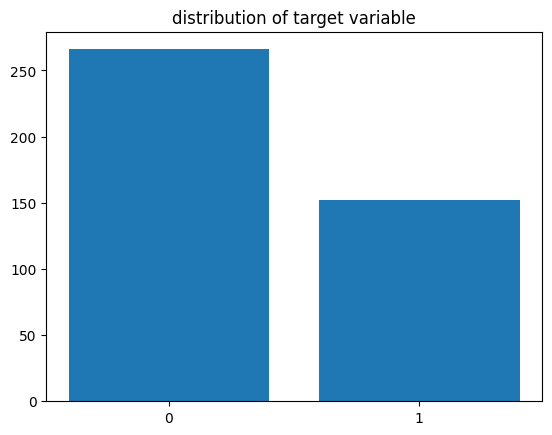

In [32]:
x=y.value_counts()
plt.bar(x.index,x)
plt.gca().set_xticks([0,1])
plt.title('distribution of target variable')
plt.show()

**What this cell does?**
*It imports the encoder tool.*

In [14]:
from sklearn.preprocessing import LabelEncoder

**What the cell does?**
*Instantiates an empty DataFrame called train and loops through columns in X. If a column contains text objects, it applies the encoder; otherwise, it copies the numbers as they are.*

In [33]:
train = pd.DataFrame()
for c in X.columns:
    if X[c].dtype == "object":
        le = LabelEncoder()
        train[c] = le.fit_transform(X[c])
    else:
        train[c] = X[c]


**What the cell does?**
*It shows a preview table, proving that text columns like Sex and Embarked are now represented as numeric codes.*

**What this cell does?**
*It removes the PassengerId column from the train DataFrame because unique identification numbers do not provide any predictive value for the machine learning model.*

In [34]:
train.drop(columns=["PassengerId"], inplace=True)


In [35]:
train.head(5)

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,3,206,1,34.5,0,0,152,7.8292,1
1,3,403,0,47.0,1,0,221,7.0000,2
2,2,269,1,62.0,0,0,73,9.6875,1
3,3,408,1,27.0,0,0,147,8.6625,2
4,3,178,0,22.0,1,1,138,12.2875,2


**What this cell does**
*Imports evaluation and modeling tools.*

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from sklearn import base

**What this cell does**
*It splits your data, teaches a  model, makes predictions, and checks the final score.*

In [37]:
def logistic(X,y):
    X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2)
    lr=LogisticRegression(max_iter=1000)
    lr.fit(X_train,y_train)
    y_pre=lr.predict(X_test)
    print('Accuracy : ',accuracy_score(y_test,y_pre))

**What this cell does**
*It uses the train data to test the model*

In [38]:
logistic(train,y)

Accuracy :  1.0


**What this cell does?**
*It calls the logistic function using the train dataset as features and y as the target, printing out the final accuracy score of the trained Logistic Regression model.*

In [39]:

from sklearn.preprocessing import OneHotEncoder

**What this cell does?**
*It imports OneHotEncoder from scikit-learn's preprocessing module to handle categorical variables by converting them into binary (0 or 1) columns.*

In [40]:
X_filtered = X.drop(columns=["PassengerId", "Name", "Ticket"], errors="ignore")

one = OneHotEncoder(sparse_output=False, drop="first")

train = one.fit_transform(X_filtered)

print("train data set has got {} rows and {} columns".format(train.shape[0], train.shape[1]))

train data set has got 418 rows and 265 columns


**What this cell does?**
*It drops unneeded text columns (PassengerId, Name, Ticket), applies one-hot encoding to the remaining features, and prints out the new shape (rows and columns) of the transformed dataset.*

In [41]:
logistic(train,y)

Accuracy :  1.0


**What this cell does?**
*It runs the logistic function once more on the newly one-hot encoded dataset to train, test, and output the updated model accuracy score.*

In [45]:
!pwd


/home/student


In [ ]:
!git init

!git remote add origin https://github.com

!git pull origin main --rebase
